<a href="https://colab.research.google.com/github/ElisabeteXavier/TECH-CHALLENGE-FASE-3/blob/main/eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [25]:
!pip install requests tqdm pandas -q

ERROR: Operation cancelled by user


In [ ]:
import requests
import json
from pathlib import Path

# Baixa o dataset do GitHub
print("⏳ Baixando PubMedQA...")
url = "https://raw.githubusercontent.com/pubmedqa/pubmedqa/master/data/ori_pqal.json"
response = requests.get(url, timeout=60)
response.raise_for_status()

# Salva o arquivo
raw_data = response.json()
with open("data/pubmedqa_raw.json", "w", encoding="utf-8") as f:
    json.dump(raw_data, f, ensure_ascii=False, indent=2)

print(f"✅ Baixado! Total de registros: {len(raw_data)}")
print("📁 Salvo em: data/pubmedqa_raw.json")

⏳ Baixando PubMedQA...
✅ Baixado! Total de registros: 1000
📁 Salvo em: data/pubmedqa_raw.json


In [15]:
import pandas as pd

# Transforma o JSON em DataFrame para visualização
linhas = []
for pmid, rec in raw_data.items():
    linhas.append({
        "pmid":        pmid,
        "pergunta":    rec.get("QUESTION", ""),
        "qtd_contextos":   len(rec.get("CONTEXTS", [])),
        "contextos": rec.get("CONTEXTS", []),# quantos contextos tem
        "resposta":    rec.get("LONG_ANSWER", "")[:200],  # primeiros 200 chars
        "label":       rec.get("final_decision", ""),
        "ano":         rec.get("YEAR", ""),
        "mesh_terms":  ", ".join(rec.get("MESHES", []))
    })

df = pd.DataFrame(linhas)
print(f"Shape: {df.shape}")
print(f"\nDistribuição de labels:")
print(df["label"].value_counts())
anos = [a for a in df['ano'].unique() if a is not None]
print(f"\nAnos disponíveis: {sorted(anos)[:10]}")



Shape: (1000, 8)

Distribuição de labels:
label
yes      552
no       338
maybe    110
Name: count, dtype: int64

Anos disponíveis: ['1989', '1990', '1992', '1993', '1994', '1995', '1996', '1997', '1998', '1999']


In [16]:
df.head(10)

,pmid,pergunta,qtd_contextos,contextos,resposta,label,ano,mesh_terms
0,21645374,Do mitochondria play a role in remodelling lac...,2,[Programmed cell death (PCD) is the regulated ...,Results depicted mitochondrial dynamics in viv...,yes,2011,"Alismataceae, Apoptosis, Cell Differentiation,..."
1,16418930,Landolt C and snellen e acuity: differences in...,3,[Assessment of visual acuity depends on the op...,"Using the charts described, there was only a s...",no,2006,"Adolescent, Adult, Aged, Aged, 80 and over, Am..."
2,9488747,"Syncope during bathing in infants, a pediatric...",2,[Apparent life-threatening events in infants a...,"""Aquagenic maladies"" could be a pediatric form...",yes,1997,"Baths, Histamine, Humans, Infant, Syncope, Urt..."
3,17208539,Are the long-term results of the transanal pul...,3,[The transanal endorectal pull-through (TERPT)...,Our long-term study showed significantly bette...,no,2007,"Child, Child, Preschool, Colectomy, Female, Hi..."
4,10808977,Can tailored interventions increase mammograph...,6,[Telephone counseling and tailored print commu...,The effects of the intervention were most pron...,yes,2000,"Cost-Benefit Analysis, Female, Health Maintena..."
5,23831910,Double balloon enteroscopy: is it efficacious ...,2,"[From March 2007 to January 2011, 88 DBE proce...",DBE appears to be equally safe and effective w...,yes,2013,"Community Health Centers, Double-Balloon Enter..."
6,26037986,30-Day and 1-year mortality in emergency gener...,3,[Emergency surgery is associated with poorer o...,Emergency laparotomy carries a high rate of mo...,maybe,2015,"Adult, Age Factors, Aged, Aged, 80 and over, C..."
7,26852225,Is adjustment for reporting heterogeneity nece...,3,[Anchoring vignettes are brief texts describin...,Sleep disorders are common in the general adul...,no,2016,"Adult, Aged, Female, Health Status Disparities..."
8,17113061,Do mutations causing low HDL-C promote increas...,3,[Although observational data support an invers...,Genetic variants identified in the present stu...,no,2007,"Cholesterol, HDL, Contrast Media, Coronary Dis..."
9,10966337,A short stay or 23-hour ward in a general and ...,3,[We evaluated the usefulness of a short stay o...,This data demonstrates the robust nature of th...,yes,2000,"Academic Medical Centers, Acute Disease, Adole..."


=== DISTRIBUIÇÃO DE LABELS ===
label
yes      552
no       338
maybe    110
Name: count, dtype: int64

Em percentual:
label
yes      55.2%
no       33.8%
maybe    11.0%
Name: proportion, dtype: object

=== VALORES NULOS POR COLUNA ===
pmid                 0
pergunta             0
qtd_contextos        0
contextos            0
resposta             0
label                0
ano                 58
mesh_terms           0
tamanho_pergunta     0
tamanho_resposta     0
dtype: int64

=== TAMANHO DAS PERGUNTAS (caracteres) ===
count    1000.0
mean       94.0
std        30.0
min        22.0
25%        73.0
50%        91.0
75%       113.0
max       213.0
Name: tamanho_pergunta, dtype: float64

=== TAMANHO DAS RESPOSTAS (caracteres) ===
count    1000.0
mean      184.0
std        30.0
min        63.0
25%       182.0
50%       200.0
75%       200.0
max       200.0
Name: tamanho_resposta, dtype: float64


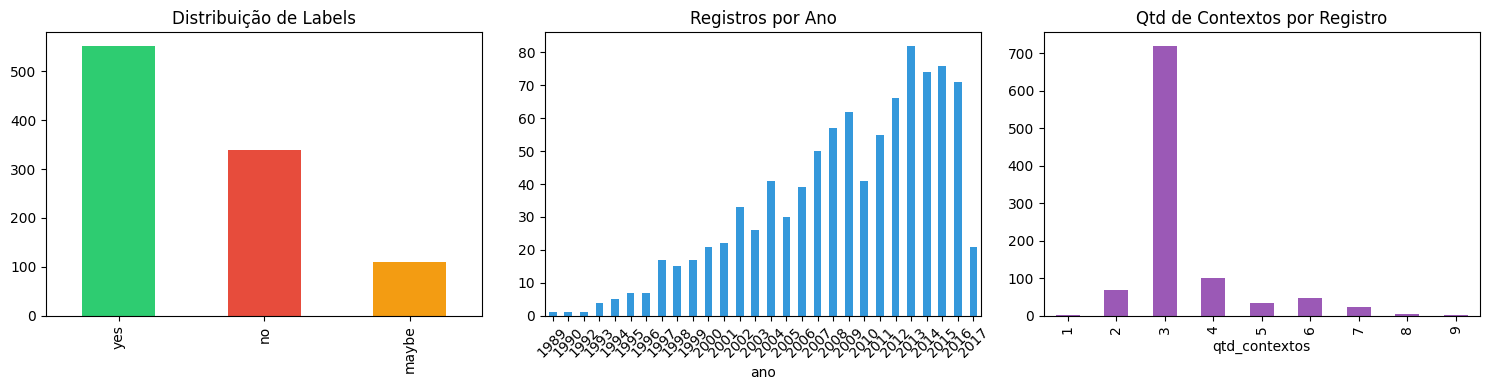

In [19]:
import matplotlib.pyplot as plt

# ── 1. Distribuição de labels ──
print("=== DISTRIBUIÇÃO DE LABELS ===")
print(df["label"].value_counts())
print(f"\nEm percentual:")
print(df["label"].value_counts(normalize=True).mul(100).round(1).astype(str) + "%")

# ── 2. Valores nulos ──
print("\n=== VALORES NULOS POR COLUNA ===")
print(df.isnull().sum())

# ── 3. Tamanho das perguntas ──
df["tamanho_pergunta"] = df["pergunta"].str.len()
print("\n=== TAMANHO DAS PERGUNTAS (caracteres) ===")
print(df["tamanho_pergunta"].describe().round(0))

# ── 4. Tamanho das respostas ──
df["tamanho_resposta"] = df["resposta"].str.len()
print("\n=== TAMANHO DAS RESPOSTAS (caracteres) ===")
print(df["tamanho_resposta"].describe().round(0))

# ── 5. Gráficos ──
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Labels
df["label"].value_counts().plot(kind="bar", ax=axes[0], color=["#2ecc71","#e74c3c","#f39c12"])
axes[0].set_title("Distribuição de Labels")
axes[0].set_xlabel("")

# Perguntas por ano
df["ano"].value_counts().sort_index().plot(kind="bar", ax=axes[1], color="#3498db")
axes[1].set_title("Registros por Ano")
axes[1].tick_params(axis='x', rotation=45)

# Número de contextos
df["qtd_contextos"].value_counts().sort_index().plot(kind="bar", ax=axes[2], color="#9b59b6")
axes[2].set_title("Qtd de Contextos por Registro")

plt.tight_layout()
plt.show()

In [24]:
for dado in df.columns:

    duplicadas = df[dado].duplicated().sum()

    print(f"{dado}: {duplicadas} duplicadas")

pmid: 0 duplicadas
pergunta: 0 duplicadas
qtd_contextos: 991 duplicadas
contextos: 0 duplicadas
resposta: 0 duplicadas
label: 997 duplicadas
ano: 971 duplicadas
mesh_terms: 0 duplicadas
tamanho_pergunta: 858 duplicadas
tamanho_resposta: 890 duplicadas


In [26]:
import re

def limpar_texto(texto):
    texto = str(texto)
    texto = re.sub(r"\s+", " ", texto)
    return texto.strip()

In [28]:
df["pergunta"] = df["pergunta"].apply(limpar_texto)

df["resposta"] = df["resposta"].apply(limpar_texto)

df["contextos"] = df["contextos"].apply(
    lambda lista: [limpar_texto(c) for c in lista]
)

In [30]:
with open("/content/drive/MyDrive/Tech-Challenge-FAse-3/data/dataset_tratado.json", "w", encoding="utf-8") as f:
    json.dump( df.to_dict(orient="records"), f, ensure_ascii=False, indent=2)
